Accuracy: 77.78%
Error Rate: 22.22%


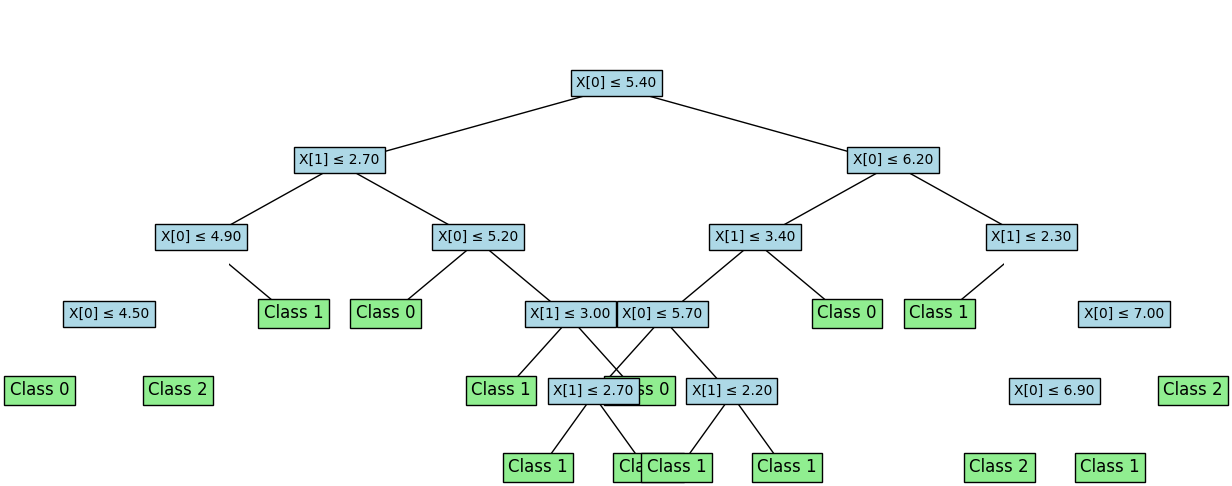

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets  

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # Use only first two features for visualization
y = iris.target

# Shuffle and split dataset
def train_test_split(X, y, test_size=0.3):
    data = np.column_stack((X, y))
    np.random.shuffle(data)
    
    split_index = int(len(data) * (1 - test_size))
    train_data, test_data = data[:split_index], data[split_index:]

    X_train, y_train = train_data[:, :-1], train_data[:, -1]
    X_test, y_test = test_data[:, :-1], test_data[:, -1]
    
    return X_train, X_test, y_train.astype(int), y_test.astype(int)

# Gini Impurity Calculation
def gini_impurity(y):
    unique_classes, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return 1 - np.sum(probs**2)

# Finding the best split
def best_split(X, y):
    best_gini = float("inf")
    best_feature, best_threshold = None, None

    for feature in range(X.shape[1]):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_mask = X[:, feature] <= threshold
            right_mask = ~left_mask
            
            left_gini = gini_impurity(y[left_mask])
            right_gini = gini_impurity(y[right_mask])
            gini = (len(y[left_mask]) * left_gini + len(y[right_mask]) * right_gini) / len(y)
            
            if gini < best_gini:
                best_gini = gini
                best_feature, best_threshold = feature, threshold
                
    return best_feature, best_threshold

# Recursive Decision Tree Building
class DecisionTree:
    def __init__(self, depth=0, max_depth=10):
        self.depth = depth
        self.max_depth = max_depth
        self.feature_index = None
        self.threshold = None
        self.left = None
        self.right = None
        self.label = None

    def fit(self, X, y):
        if len(set(y)) == 1:  # Pure node (all same class)
            self.label = y[0]
            return

        if self.depth >= self.max_depth:  # Max depth reached
            self.label = np.bincount(y).argmax()
            return
        
        feature, threshold = best_split(X, y)
        if feature is None:
            self.label = np.bincount(y).argmax()
            return
        
        self.feature_index = feature
        self.threshold = threshold

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        self.left = DecisionTree(depth=self.depth + 1, max_depth=self.max_depth)
        self.left.fit(X[left_mask], y[left_mask])

        self.right = DecisionTree(depth=self.depth + 1, max_depth=self.max_depth)
        self.right.fit(X[right_mask], y[right_mask])

    def predict(self, X):
        if self.label is not None:
            return self.label
        
        if X[self.feature_index] <= self.threshold:
            return self.left.predict(X)
        else:
            return self.right.predict(X)

# Evaluate Accuracy
def evaluate(tree, X_test, y_test):
    predictions = np.array([tree.predict(x) for x in X_test])
    accuracy = np.sum(predictions == y_test) / len(y_test)
    error_rate = 1 - accuracy
    return accuracy, error_rate

# Train and Test the Decision Tree
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
tree = DecisionTree(max_depth=5)
tree.fit(X_train, y_train)

accuracy, error_rate = evaluate(tree, X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Error Rate: {error_rate * 100:.2f}%")

# ------------------ Visualization Functions ------------------ #
import matplotlib.pyplot as plt
import numpy as np

# Recursive function to plot the decision tree
def plot_tree(ax, tree, x=0, y=0, dx=5, dy=2, depth=0, parent_coords=None):
    if tree.label is not None:  # Leaf node
        ax.text(x, y, f"Class {tree.label}", fontsize=12, ha='center', bbox=dict(facecolor='lightgreen', edgecolor='black'))
    else:  # Internal node
        ax.text(x, y, f"X[{tree.feature_index}] ≤ {tree.threshold:.2f}", fontsize=10, ha='center', bbox=dict(facecolor='lightblue', edgecolor='black'))
    
    # Draw connecting lines
    if parent_coords:
        ax.plot([parent_coords[0], x], [parent_coords[1], y], 'k-', lw=1)

    # Recur for left and right children
    if tree.left:
        plot_tree(ax, tree.left, x - dx/(depth+1), y - dy, dx, dy, depth + 1, (x, y))
    if tree.right:
        plot_tree(ax, tree.right, x + dx/(depth+1), y - dy, dx, dy, depth + 1, (x, y))

# Function to display the decision tree structure
def visualize_tree(tree):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(-7, 7)
    ax.set_ylim(-10, 2)
    ax.axis('off')  # Hide axis
    plot_tree(ax, tree)
    plt.show()

# Visualize the trained Decision Tree
visualize_tree(tree)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn import datasets

# Loaddataset
iris = datasets.load_iris()
X = iris.data  # Features
y = iris.target  # Target labels (0, 1, 2)
feature_names = iris.feature_names

# Shuffle 
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.7 * len(X))  # 70-30 split
X_train, X_test = X[indices[:train_size]], X[indices[train_size:]]
y_train, y_test = y[indices[:train_size]], y[indices[train_size:]]


In [3]:
class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, label=None):
        self.feature_index = feature_index  # Feature use splitting
        self.threshold = threshold  # Split point
        self.left = left  # Left subtree
        self.right = right  # Right subtree
        self.label = label  # Class label 

In [4]:
def gini_impurity(y):
  
    counts = Counter(y)
    impurity = 1 - sum((count / len(y)) ** 2 for count in counts.values())
    return impurity

In [5]:
def best_split(X, y):
    best_feature, best_threshold, best_gini = None, None, float('inf')
    
    for feature_index in range(X.shape[1]):
        thresholds = np.unique(X[:, feature_index])
        for threshold in thresholds:
            left_indices = X[:, feature_index] <= threshold
            right_indices = ~left_indices
            
            if sum(left_indices) == 0 or sum(right_indices) == 0:
                continue
            
            left_gini = gini_impurity(y[left_indices])
            right_gini = gini_impurity(y[right_indices])
            gini = (sum(left_indices) * left_gini + sum(right_indices) * right_gini) / len(y)
            
            if gini < best_gini:
                best_feature, best_threshold, best_gini = feature_index, threshold, gini
                
    return best_feature, best_threshold

In [6]:
def build_tree(X, y, depth=0):
    if len(set(y)) == 1:  # If all labels are same, create a leaf node
        return Node(label=y[0])
    
    best_feature, best_threshold = best_split(X, y)
    
    if best_feature is None:
        return Node(label=Counter(y).most_common(1)[0][0])
    
    left_indices = X[:, best_feature] <= best_threshold
    right_indices = ~left_indices
    
    left_subtree = build_tree(X[left_indices], y[left_indices], depth + 1)
    right_subtree = build_tree(X[right_indices], y[right_indices], depth + 1)
    
    return Node(feature_index=best_feature, threshold=best_threshold, left=left_subtree, right=right_subtree)




In [7]:
# Train decision tree
tree = build_tree(X_train, y_train)

In [8]:
def predict(tree, x):
    if tree.label is not None:
        return tree.label
    if x[tree.feature_index] <= tree.threshold:
        return predict(tree.left, x)
    else:
        return predict(tree.right, x)

# Predict on test 
y_pred = np.array([predict(tree, x) for x in X_test])

#accuracy and error rate
accuracy = np.mean(y_pred == y_test) * 100
error_rate = 100 - accuracy

print(f"Accuracy: {accuracy:.2f}%")
print(f"Error Rate: {error_rate:.2f}%")


Accuracy: 95.56%
Error Rate: 4.44%


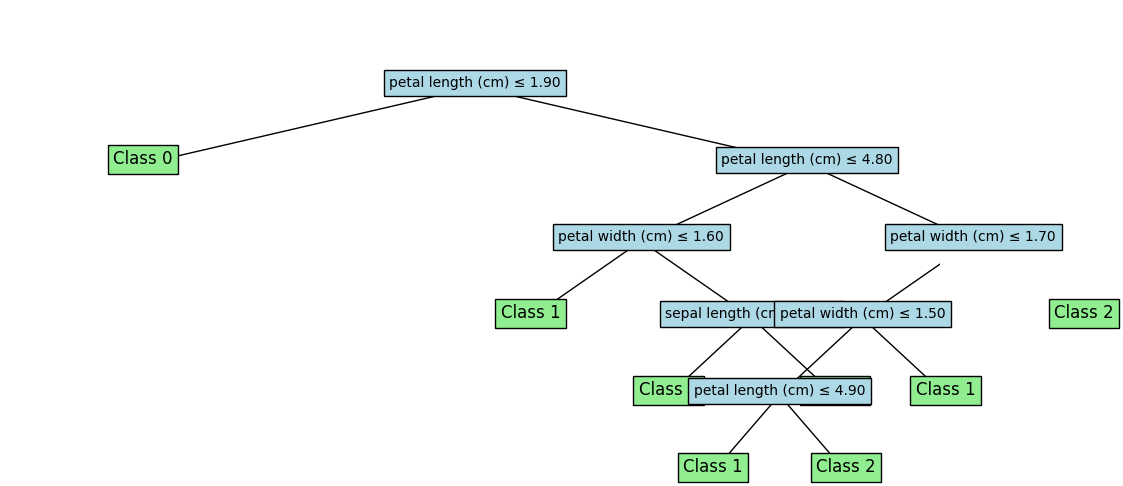

In [9]:
def plot_tree(ax, tree, x=0, y=0, dx=5, dy=2, depth=0, parent_coords=None):
    if tree.label is not None:  # Leaf node
        ax.text(x, y, f"Class {tree.label}", fontsize=12, ha='center', 
                bbox=dict(facecolor='lightgreen', edgecolor='black'))
    else:  # Internal node
        feature = feature_names[tree.feature_index]
        ax.text(x, y, f"{feature} ≤ {tree.threshold:.2f}", fontsize=10, ha='center',
                bbox=dict(facecolor='lightblue', edgecolor='black'))
    
    # Draw connecting lines
    if parent_coords:
        ax.plot([parent_coords[0], x], [parent_coords[1], y], 'k-', lw=1)

    # Recur for left and right children
    if tree.left:
        plot_tree(ax, tree.left, x - dx/(depth+1), y - dy, dx, dy, depth + 1, (x, y))
    if tree.right:
        plot_tree(ax, tree.right, x + dx/(depth+1), y - dy, dx, dy, depth + 1, (x, y))

# visualize 
def visualize_tree(tree):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(-7, 7)
    ax.set_ylim(-10, 2)
    ax.axis('off')  
    plot_tree(ax, tree)
    plt.show()

visualize_tree(tree)


In [10]:
#Question 2 

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Load dataset
breast_cancer = datasets.load_breast_cancer()
X = breast_cancer.data  
y = breast_cancer.target  

#bias 
X = np.c_[np.ones((X.shape[0], 1)), X]

# Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


# Cost function
def compute_cost(X, y, weights):
    m = len(y)
    predictions = sigmoid(X @ weights)
    predictions = np.clip(predictions, 1e-10, 1 - 1e-10)  # Clip to avoid log(0)
    
    cost = -(1/m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    return cost


# Gradient Descent for Logistic Regression
def gradient_descent(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    weights = np.zeros(n)
    cost_history = []

    for _ in range(epochs):
        predictions = sigmoid(X @ weights)
        gradient = (1/m) * X.T @ (predictions - y)
        weights -= lr * gradient
        cost_history.append(compute_cost(X, y, weights))

    return weights, cost_history

# Train
weights, cost_history = gradient_descent(X_train, y_train, lr=0.01, epochs=2000)


In [13]:
# Predict fxn
def predict(X, weights, threshold=0.5):
    return (sigmoid(X @ weights) >= threshold).astype(int)

# Predictions
y_pred = predict(X_test, weights)


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print("Confusion Matrix:")
print(conf_matrix)


Accuracy: 94.74%
Precision: 98.51%
Recall: 92.96%
Confusion Matrix:
[[42  1]
 [ 5 66]]


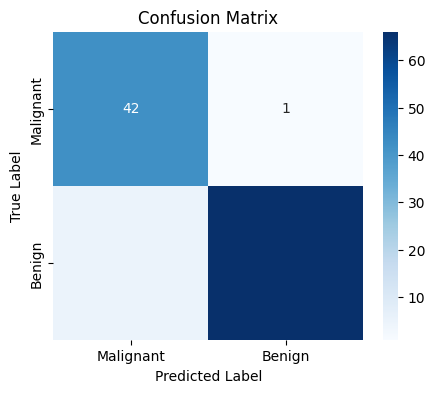

In [15]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
